### CONFIGURACIÓN E IMPORTS

In [3]:
import torch
print(f"¿GPU disponible? {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memoria GPU: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("⚠️ No hay GPU, se usará CPU (más lento)")

# Imports principales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
import time
import re
import string

warnings.filterwarnings('ignore')

# Configurar estilo de gráficas
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Imports para NLP
from wordcloud import WordCloud, STOPWORDS

# Imports para Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error,
    silhouette_score, confusion_matrix, classification_report
)

# Imports para Deep Learning
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import get_linear_schedule_with_warmup

print("\n" + "="*70)
print("🎯 DETECCIÓN DE AGRESIVIDAD, MANIPULACIÓN Y SARCASMO")
print("   Análisis Exploratorio + Modelado BERT")
print("="*70)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n✅ Dispositivo: {device}")

¿GPU disponible? False
⚠️ No hay GPU, se usará CPU (más lento)

🎯 DETECCIÓN DE AGRESIVIDAD, MANIPULACIÓN Y SARCASMO
   Análisis Exploratorio + Modelado BERT

✅ Dispositivo: cpu


In [11]:
CSV_PATH = 'Data.csv'

try:
    df = pd.read_csv(CSV_PATH)
    print(f"CSV cargado exitosamente!")
    print(f"Total de registros: {len(df)}")
    print(f"Columnas: {df.columns.tolist()}")
    
    # Verificar columnas necesarias
    columnas_necesarias = ['frase', 'agresividad', 'manipulacion', 'sarcasmo']
    for col in columnas_necesarias:
        if col not in df.columns:
            raise ValueError(f"❌ Falta la columna '{col}'")
    
    print(f"Todas las columnas necesarias presentes")
    
except FileNotFoundError:
    print(f"No se encontró: {CSV_PATH}")
    print("\nFormato esperado:")
    print("frase,agresividad,manipulacion,sarcasmo")
    print("es que yo soy diferente,0.2,0.7,0.1")
    raise


CSV cargado exitosamente!
Total de registros: 847
Columnas: ['frase', 'agresividad', 'manipulacion', 'sarcasmo']
Todas las columnas necesarias presentes


In [12]:
print(f"\nDimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"\nTipos de datos:")
print(df.dtypes)


Dimensiones: 847 filas × 4 columnas

Tipos de datos:
frase               str
agresividad     float64
manipulacion    float64
sarcasmo        float64
dtype: object


In [13]:
print(f"\nValores nulos:")
print(df.isnull().sum())



Valores nulos:
frase           0
agresividad     0
manipulacion    0
sarcasmo        0
dtype: int64


In [14]:
print(f"\nPrimeras 5 filas:")
display(df.head())


Primeras 5 filas:


,frase,agresividad,manipulacion,sarcasmo
0,es que yo soy diferente al resto de los hombres,0.2,0.7,0.1
1,Es que a mi nadie me da pelota yo siempre soy ...,0.2,0.9,0.1
2,todo lo malo que le pasa es tu culpa,0.9,0.8,0.0
3,¿Le estás enviando mensajes a esa chica coquet...,0.3,0.6,0.2
4,¿Qué? ¿No puedo hablar con mis amigos?!,0.7,0.5,0.4


In [15]:

print(f"\nÚltimas 5 filas:")
display(df.tail())


Últimas 5 filas:


,frase,agresividad,manipulacion,sarcasmo
842,"pero bueno, supongo que así quedó",0.0,0.2,0.1
843,igual suerte con lo tuyo,0.0,0.1,0.1
844,"espero que te vaya bien, en serio",0.0,0.1,0.1
845,yo ya no voy a meterme más,0.0,0.2,0.1
846,En serio vas a terminar solo por esto,0.2,0.6,0.2


### LIMPIEZA DE DATOS

In [17]:
def limpiar_texto(texto):
    """Limpieza completa de texto"""
    if pd.isna(texto):
        return ""
    texto = str(texto).lower().strip()
    # Mantener caracteres útiles para español
    texto = re.sub(r'[^\w\sáéíóúñü¿¡.,;!?]', '', texto)
    # Eliminar espacios múltiples
    texto = re.sub(r'\s+', ' ', texto)
    return texto.strip()

def contar_palabras(texto):
    """Cuenta palabras en un texto"""
    if pd.isna(texto) or texto == "":
        return 0
    return len(str(texto).split())

def contar_caracteres(texto):
    """Cuenta caracteres en un texto"""
    if pd.isna(texto):
        return 0
    return len(str(texto))

# Aplicar limpieza
df['frase_limpia'] = df['frase'].apply(limpiar_texto)

# Crear características de texto
df['num_palabras'] = df['frase'].apply(contar_palabras)
df['num_caracteres'] = df['frase'].apply(contar_caracteres)
df['longitud_promedio_palabra'] = df['num_caracteres'] / (df['num_palabras'] + 1)

# Verificar duplicados
duplicados = df['frase_limpia'].duplicated().sum()
print(f"Frases duplicadas: {duplicados}")

if duplicados > 0:
    print(f"Eliminando duplicados...")
    df = df.drop_duplicates(subset=['frase_limpia']).reset_index(drop=True)
    print(f"Registros después de eliminar duplicados: {len(df)}")

# Verificar valores atípicos en las etiquetas
print(f"\nRango de las etiquetas:")
for col in ['agresividad', 'manipulacion', 'sarcasmo']:
    print(f"   {col}: [{df[col].min():.2f}, {df[col].max():.2f}]")

# Asegurar que los valores estén en [0, 1]
for col in ['agresividad', 'manipulacion', 'sarcasmo']:
    df[col] = df[col].clip(0, 1)

print(f"\nLimpieza completada. Total final: {len(df)} registros")

Frases duplicadas: 0

Rango de las etiquetas:
   agresividad: [0.00, 0.90]
   manipulacion: [0.10, 0.90]
   sarcasmo: [0.00, 0.70]

Limpieza completada. Total final: 844 registros


### ANÁLISIS UNIVARIADO - ESTADÍSTICAS DESCRIPTIVAS

In [ ]:
# Estadísticas de las variables objetivo
print("\nEstadísticas de las variables objetivo:")
display(df[['agresividad', 'manipulacion', 'sarcasmo']].describe().round(4))


Estadísticas de las variables objetivo:


,agresividad,manipulacion,sarcasmo
count,844.0000,844.0000,844.0000
mean,0.2812,0.4871,0.2467
std,0.1905,0.1521,0.1203
min,0.0000,0.1000,0.0000
25%,0.1000,0.4000,0.2000
50%,0.2000,0.5000,0.2000
75%,0.4000,0.6000,0.3000
max,0.9000,0.9000,0.7000


In [ ]:
# Estadísticas de las características de texto
print("\nEstadísticas de las características de texto:")
display(df[['num_palabras', 'num_caracteres', 'longitud_promedio_palabra']].describe().round(4))


Estadísticas de las características de texto:


,num_palabras,num_caracteres,longitud_promedio_palabra
count,844.0000,844.0000,844.0000
mean,7.1730,37.9834,4.6030
std,3.3166,17.3050,0.8209
min,1.0000,2.0000,1.0000
25%,5.0000,26.0000,4.0000
50%,7.0000,36.0000,4.5590
75%,9.0000,48.0000,5.1380
max,24.0000,138.0000,7.6667


In [ ]:
# Medidas de tendencia central y dispersión
print("\n📊 Medidas adicionales:")
for col in ['agresividad', 'manipulacion', 'sarcasmo']:
    print(f"\n🔴 {col.upper()}:")
    print(f"   Media: {df[col].mean():.4f}")
    print(f"   Mediana: {df[col].median():.4f}")
    print(f"   Moda: {df[col].mode().values[0]:.4f}")
    print(f"   Varianza: {df[col].var():.4f}")
    print(f"   Desv. Estándar: {df[col].std():.4f}")
    print(f"   Asimetría (Skewness): {df[col].skew():.4f}")
    print(f"   Curtosis: {df[col].kurtosis():.4f}")
    print(f"   Rango IQR: {df[col].quantile(0.75) - df[col].quantile(0.25):.4f}")


📊 Medidas adicionales:

🔴 AGRESIVIDAD:
   Media: 0.2812
   Mediana: 0.2000
   Moda: 0.2000
   Varianza: 0.0363
   Desv. Estándar: 0.1905
   Asimetría (Skewness): 0.7819
   Curtosis: 0.3072
   Rango IQR: 0.3000

🔴 MANIPULACION:
   Media: 0.4871
   Mediana: 0.5000
   Moda: 0.5000
   Varianza: 0.0231
   Desv. Estándar: 0.1521
   Asimetría (Skewness): 0.0327
   Curtosis: -0.3135
   Rango IQR: 0.2000

🔴 SARCASMO:
   Media: 0.2467
   Mediana: 0.2000
   Moda: 0.2000
   Varianza: 0.0145
   Desv. Estándar: 0.1203
   Asimetría (Skewness): 0.7645
   Curtosis: 0.8120
   Rango IQR: 0.1000


### ANÁLISIS UNIVARIADO - DISTRIBUCIONES DE VARIABLES OBJETIVO

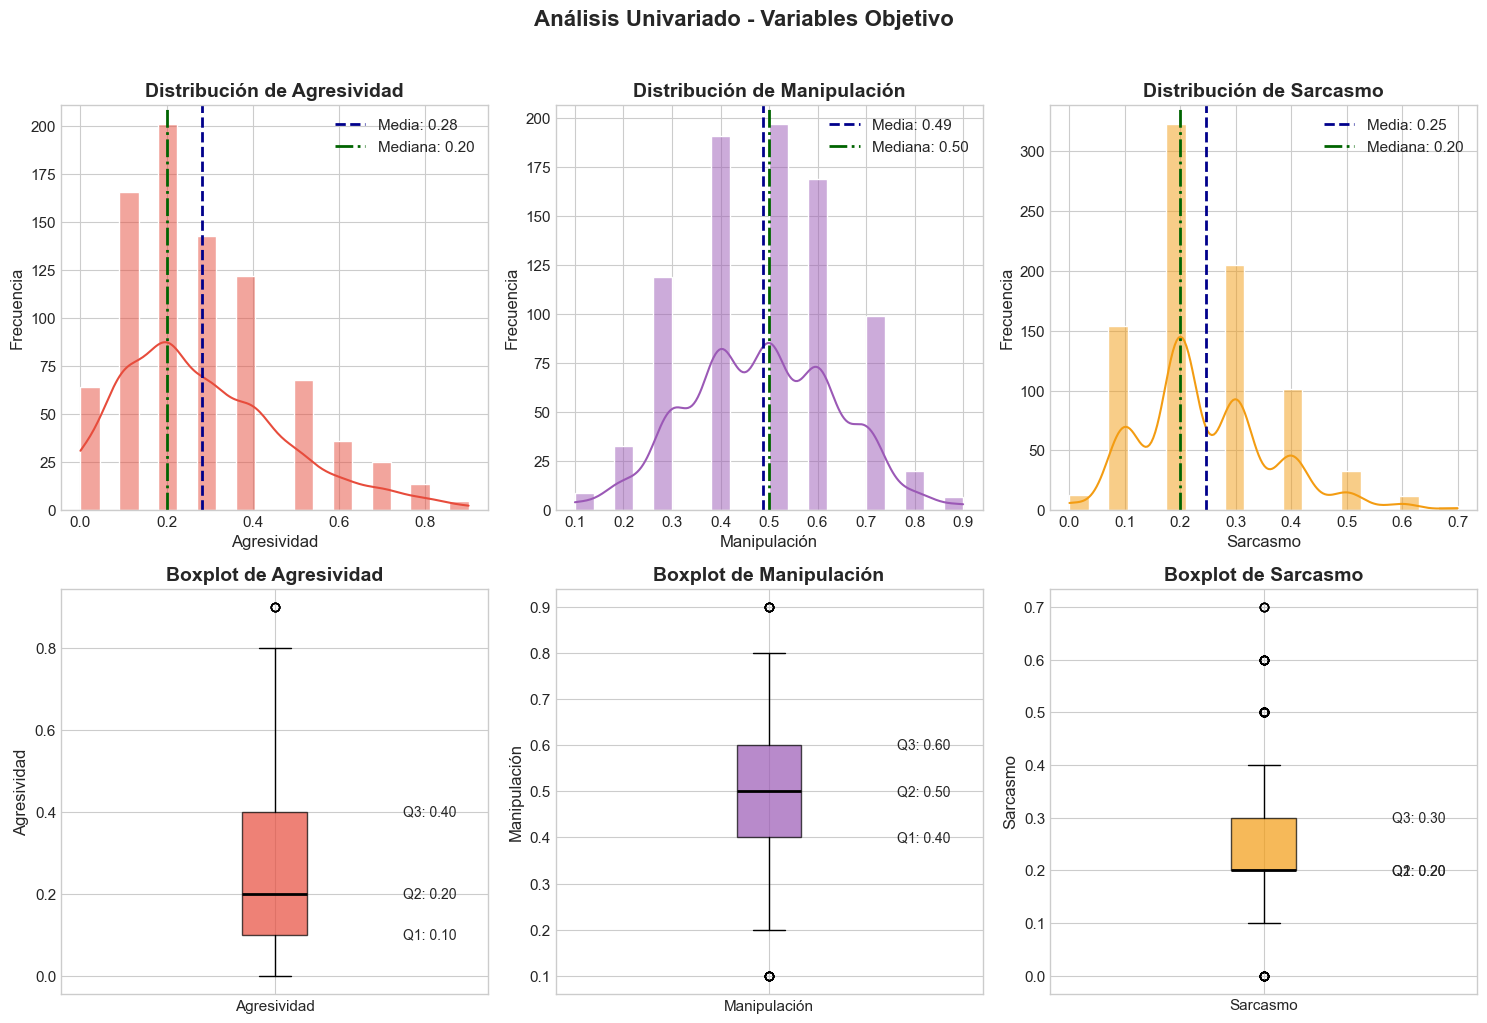

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

colores = ['#e74c3c', '#9b59b6', '#f39c12']
nombres = ['Agresividad', 'Manipulación', 'Sarcasmo']
columnas = ['agresividad', 'manipulacion', 'sarcasmo']

# Fila 1: Histogramas
for idx, (col, nombre, color) in enumerate(zip(columnas, nombres, colores)):
    ax = axes[0, idx]
    sns.histplot(data=df, x=col, bins=20, kde=True, color=color, ax=ax, edgecolor='white')
    ax.axvline(df[col].mean(), color='darkblue', linestyle='--', linewidth=2, label=f'Media: {df[col].mean():.2f}')
    ax.axvline(df[col].median(), color='darkgreen', linestyle='-.', linewidth=2, label=f'Mediana: {df[col].median():.2f}')
    ax.set_title(f'Distribución de {nombre}', fontsize=14, fontweight='bold')
    ax.set_xlabel(nombre, fontsize=12)
    ax.set_ylabel('Frecuencia', fontsize=12)
    ax.legend(loc='upper right')

# Fila 2: Boxplots
for idx, (col, nombre, color) in enumerate(zip(columnas, nombres, colores)):
    ax = axes[1, idx]
    bp = ax.boxplot(df[col], patch_artist=True, boxprops=dict(facecolor=color, alpha=0.7),
                    medianprops=dict(color='black', linewidth=2))
    ax.set_title(f'Boxplot de {nombre}', fontsize=14, fontweight='bold')
    ax.set_ylabel(nombre, fontsize=12)
    ax.set_xticklabels([nombre])
    
    # Anotar cuartiles
    q1, q2, q3 = df[col].quantile([0.25, 0.5, 0.75])
    ax.text(1.3, q1, f'Q1: {q1:.2f}', va='center', fontsize=10)
    ax.text(1.3, q2, f'Q2: {q2:.2f}', va='center', fontsize=10)
    ax.text(1.3, q3, f'Q3: {q3:.2f}', va='center', fontsize=10)

plt.suptitle('Análisis Univariado - Variables Objetivo', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('01_distribuciones_objetivo.png', dpi=150, bbox_inches='tight')
plt.show()

### ANÁLISIS UNIVARIADO - CARACTERÍSTICAS DE TEXTO

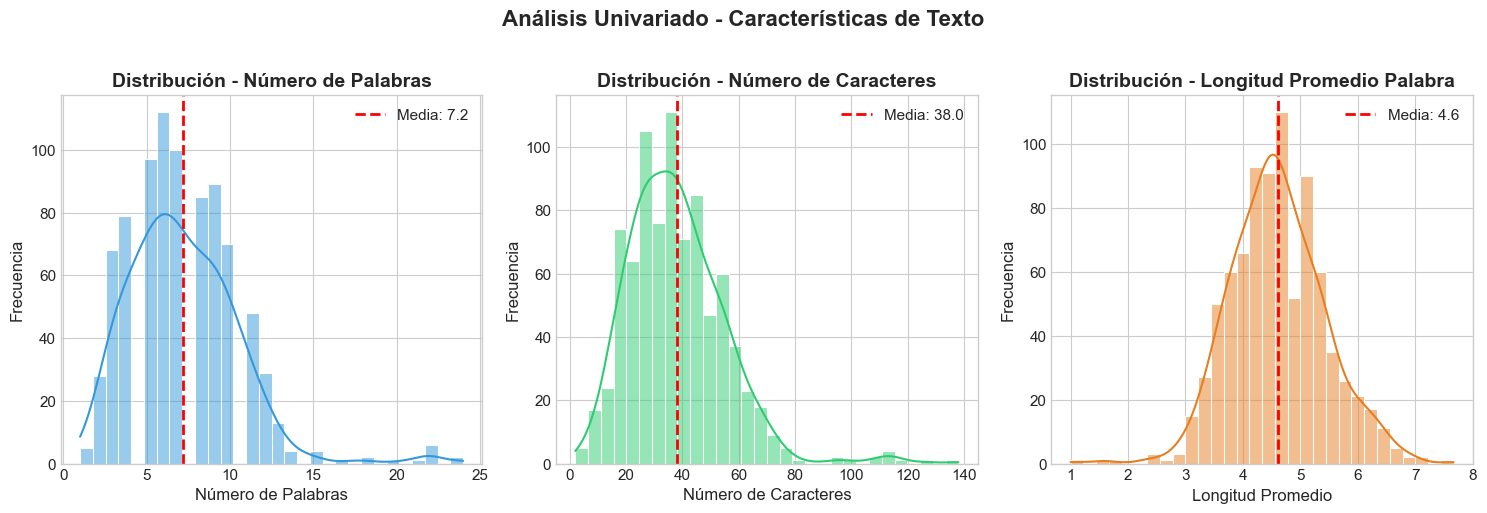

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Distribución de número de palabras
ax1 = axes[0]
sns.histplot(data=df, x='num_palabras', bins=30, kde=True, color='#3498db', ax=ax1, edgecolor='white')
ax1.axvline(df['num_palabras'].mean(), color='red', linestyle='--', linewidth=2, 
            label=f'Media: {df["num_palabras"].mean():.1f}')
ax1.set_title('Distribución - Número de Palabras', fontsize=14, fontweight='bold')
ax1.set_xlabel('Número de Palabras')
ax1.set_ylabel('Frecuencia')
ax1.legend()

# Distribución de número de caracteres
ax2 = axes[1]
sns.histplot(data=df, x='num_caracteres', bins=30, kde=True, color='#2ecc71', ax=ax2, edgecolor='white')
ax2.axvline(df['num_caracteres'].mean(), color='red', linestyle='--', linewidth=2,
            label=f'Media: {df["num_caracteres"].mean():.1f}')
ax2.set_title('Distribución - Número de Caracteres', fontsize=14, fontweight='bold')
ax2.set_xlabel('Número de Caracteres')
ax2.set_ylabel('Frecuencia')
ax2.legend()

# Distribución de longitud promedio de palabra
ax3 = axes[2]
sns.histplot(data=df, x='longitud_promedio_palabra', bins=30, kde=True, color='#e67e22', ax=ax3, edgecolor='white')
ax3.axvline(df['longitud_promedio_palabra'].mean(), color='red', linestyle='--', linewidth=2,
            label=f'Media: {df["longitud_promedio_palabra"].mean():.1f}')
ax3.set_title('Distribución - Longitud Promedio Palabra', fontsize=14, fontweight='bold')
ax3.set_xlabel('Longitud Promedio')
ax3.set_ylabel('Frecuencia')
ax3.legend()

plt.suptitle('Análisis Univariado - Características de Texto', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('02_distribuciones_texto.png', dpi=150, bbox_inches='tight')
plt.show()

### ANÁLISIS BIVARIADO - CORRELACIONES

In [26]:
# Matriz de correlación de variables objetivo
corr_objetivo = df[['agresividad', 'manipulacion', 'sarcasmo']].corr()

print("\nMatriz de Correlación (Variables Objetivo):")
print(corr_objetivo.round(4))


Matriz de Correlación (Variables Objetivo):
              agresividad  manipulacion  sarcasmo
agresividad        1.0000        0.4566   -0.1723
manipulacion       0.4566        1.0000   -0.1492
sarcasmo          -0.1723       -0.1492    1.0000


In [28]:
# Interpretación de correlaciones
print("\nInterpretación de correlaciones:")
for i, col1 in enumerate(columnas):
    for j, col2 in enumerate(columnas):
        if i < j:
            corr = corr_objetivo.loc[col1, col2]
            if abs(corr) > 0.7:
                fuerza = "FUERTE"
            elif abs(corr) > 0.4:
                fuerza = "MODERADA"
            elif abs(corr) > 0.2:
                fuerza = "DÉBIL"
            else:
                fuerza = "MUY DÉBIL"
            direccion = "positiva" if corr > 0 else "negativa"
            print(f"   {col1} ↔ {col2}: {corr:.4f} ({fuerza} {direccion})")


Interpretación de correlaciones:
   agresividad ↔ manipulacion: 0.4566 (MODERADA positiva)
   agresividad ↔ sarcasmo: -0.1723 (MUY DÉBIL negativa)
   manipulacion ↔ sarcasmo: -0.1492 (MUY DÉBIL negativa)


In [29]:
# Matriz de correlación completa (incluyendo características de texto)
corr_completa = df[['agresividad', 'manipulacion', 'sarcasmo', 
                    'num_palabras', 'num_caracteres', 'longitud_promedio_palabra']].corr()

print(f"\nMatriz de Correlación Completa:")
print(corr_completa.round(4))


Matriz de Correlación Completa:
                           agresividad  manipulacion  sarcasmo  num_palabras  \
agresividad                     1.0000        0.4566   -0.1723       -0.1743   
manipulacion                    0.4566        1.0000   -0.1492        0.1916   
sarcasmo                       -0.1723       -0.1492    1.0000        0.2622   
num_palabras                   -0.1743        0.1916    0.2622        1.0000   
num_caracteres                 -0.1425        0.2249    0.2870        0.9404   
longitud_promedio_palabra       0.0692        0.1963    0.1393        0.1335   

                           num_caracteres  longitud_promedio_palabra  
agresividad                       -0.1425                     0.0692  
manipulacion                       0.2249                     0.1963  
sarcasmo                           0.2870                     0.1393  
num_palabras                       0.9404                     0.1335  
num_caracteres                     1.0000          

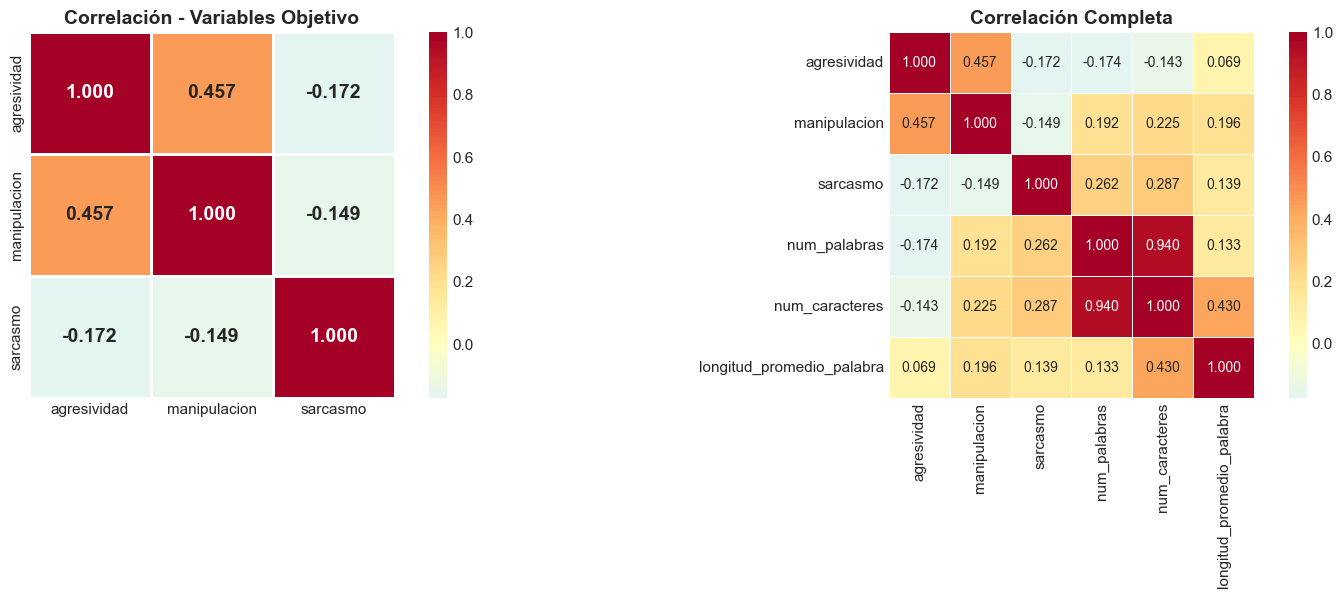

In [ ]:
# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap variables objetivo
ax1 = axes[0]
mask = np.triu(np.ones_like(corr_objetivo, dtype=bool), k=1)
sns.heatmap(corr_objetivo, annot=True, fmt='.3f', cmap='RdYlBu_r', 
            center=0, ax=ax1, square=True, linewidths=1,
            annot_kws={'size': 14, 'fontweight': 'bold'})
ax1.set_title('Correlación - Variables Objetivo', fontsize=14, fontweight='bold')

# Heatmap completo
ax2 = axes[1]
sns.heatmap(corr_completa, annot=True, fmt='.3f', cmap='RdYlBu_r',
            center=0, ax=ax2, square=True, linewidths=0.5,
            annot_kws={'size': 10})
ax2.set_title('Correlación Completa', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('03_correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()

### ANÁLISIS BIVARIADO - SCATTER PLOTS

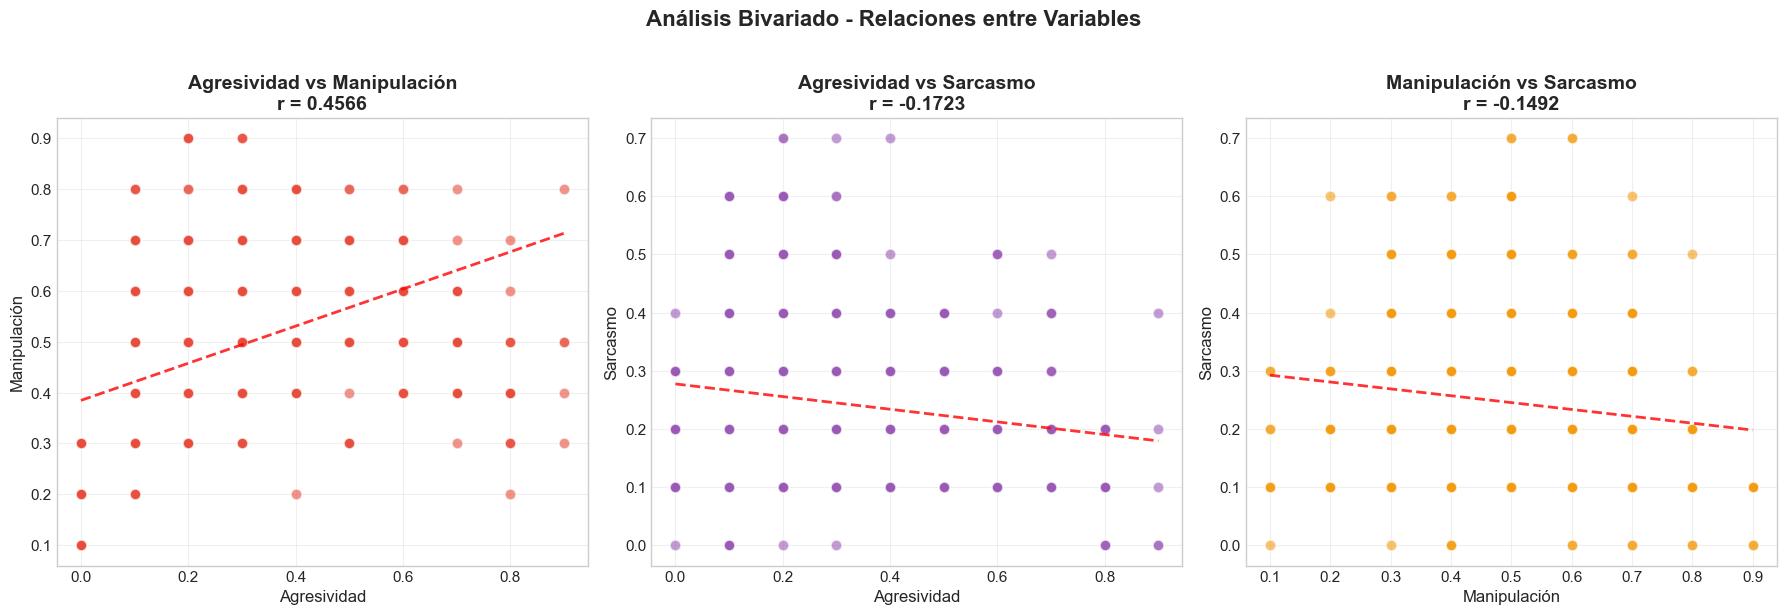

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

combinaciones = [
    ('agresividad', 'manipulacion', '#e74c3c', 'Agresividad', 'Manipulación'),
    ('agresividad', 'sarcasmo', '#9b59b6', 'Agresividad', 'Sarcasmo'),
    ('manipulacion', 'sarcasmo', '#f39c12', 'Manipulación', 'Sarcasmo')
]

for idx, (x_col, y_col, color, x_name, y_name) in enumerate(combinaciones):
    ax = axes[idx]
    
    # Scatter plot
    ax.scatter(df[x_col], df[y_col], alpha=0.6, color=color, edgecolors='white', s=60)
    
    # Línea de tendencia
    z = np.polyfit(df[x_col], df[y_col], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[x_col].min(), df[x_col].max(), 100)
    ax.plot(x_line, p(x_line), 'r--', linewidth=2, alpha=0.8)
    
    # Correlación
    corr = df[x_col].corr(df[y_col])
    
    ax.set_xlabel(x_name, fontsize=12)
    ax.set_ylabel(y_name, fontsize=12)
    ax.set_title(f'{x_name} vs {y_name}\nr = {corr:.4f}', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.suptitle('Análisis Bivariado - Relaciones entre Variables', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('04_scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()

### ANÁLISIS BIVARIADO - RELACIÓN CON LONGITUD DEL TEXTO

IndexError: index 2 is out of bounds for axis 0 with size 2

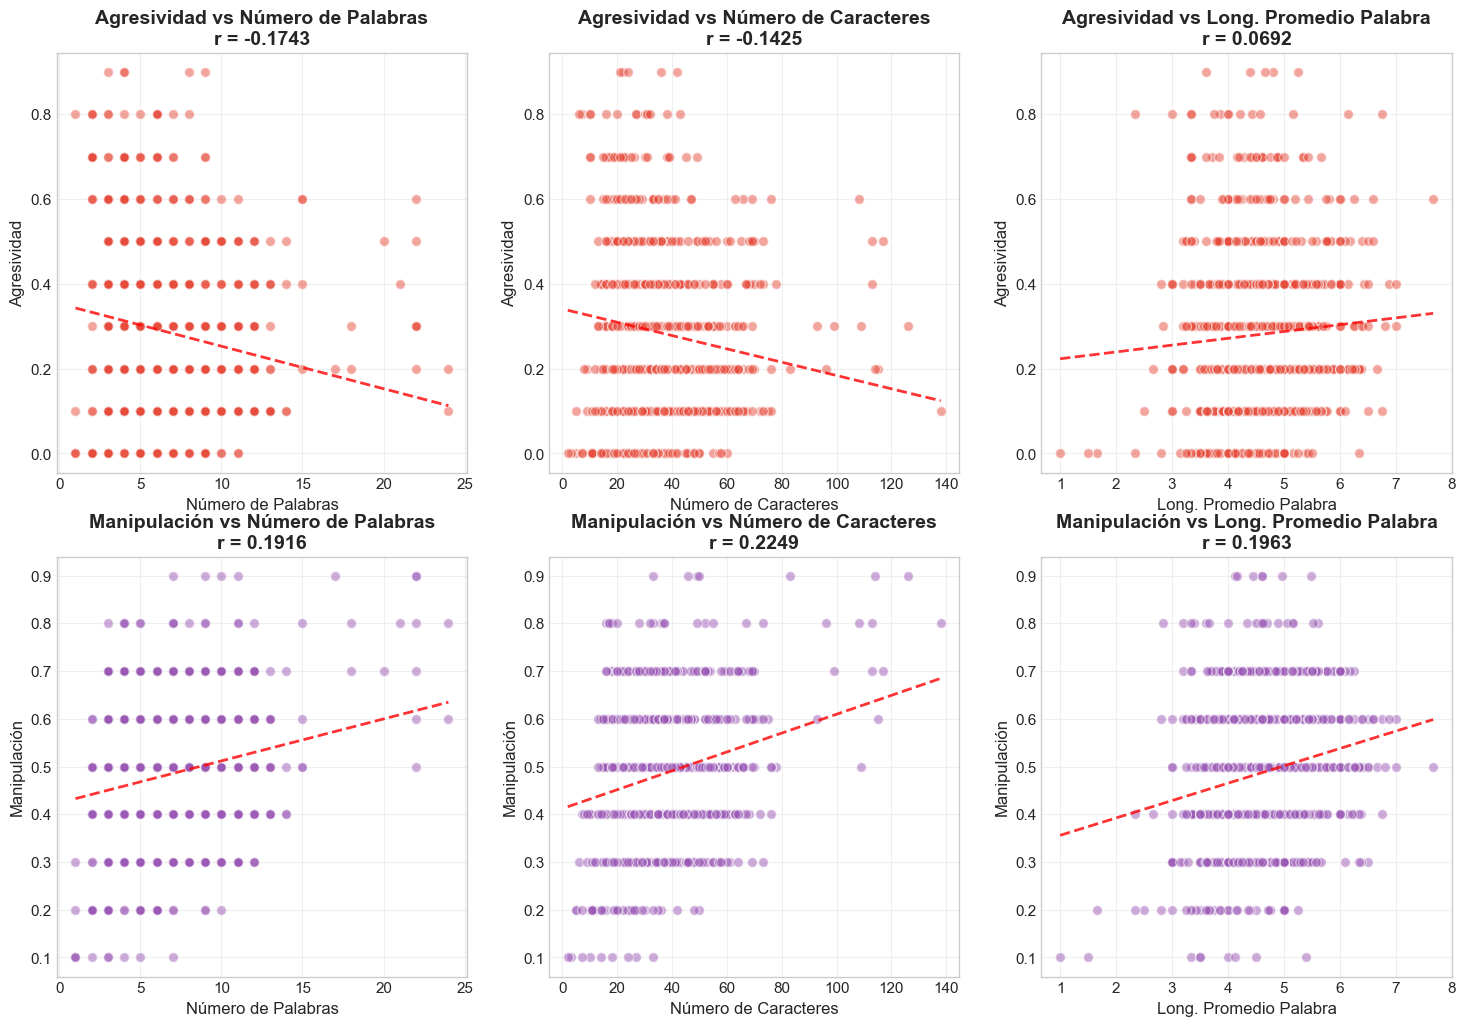

In [33]:

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

caracteristicas = ['num_palabras', 'num_caracteres', 'longitud_promedio_palabra']
nombres_caract = ['Número de Palabras', 'Número de Caracteres', 'Long. Promedio Palabra']

for row, col_obj in enumerate(columnas):
    for col_idx, (caract, nom_caract) in enumerate(zip(caracteristicas, nombres_caract)):
        ax = axes[row, col_idx]
        
        # Scatter
        ax.scatter(df[caract], df[col_obj], alpha=0.5, color=colores[row], edgecolors='white', s=50)
        
        # Línea de tendencia
        z = np.polyfit(df[caract], df[col_obj], 1)
        p = np.poly1d(z)
        x_line = np.linspace(df[caract].min(), df[caract].max(), 100)
        ax.plot(x_line, p(x_line), 'r--', linewidth=2, alpha=0.8)
        
        corr = df[caract].corr(df[col_obj])
        ax.set_xlabel(nom_caract)
        ax.set_ylabel(nombres[row])
        ax.set_title(f'{nombres[row]} vs {nom_caract}\nr = {corr:.4f}', fontweight='bold')
        ax.grid(True, alpha=0.3)

plt.suptitle('Relación entre Variables Objetivo y Características de Texto', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('05_relacion_longitud.png', dpi=150, bbox_inches='tight')
plt.show()

### NUBES DE PALABRAS - GENERAL Y POR CATEGORÍA

In [35]:
# Stopwords en español
stopwords_es = set(STOPWORDS)
stopwords_es.update(['que', 'que', 'de', 'la', 'el', 'en', 'y', 'a', 'los', 'las', 
                     'del', 'se', 'un', 'una', 'por', 'con', 'para', 'no', 'es', 'lo',
                     'su', 'al', 'como', 'más', 'pero', 'sus', 'le', 'ya', 'o', 'fue',
                     'este', 'ha', 'sí', 'porque', 'esta', 'son', 'entre', 'está',
                     'cuando', 'muy', 'sin', 'sobre', 'ser', 'también', 'me', 'hasta',
                     'hay', 'donde', 'quien', 'desde', 'todo', 'nos', 'durante', 'todos',
                     'uno', 'les', 'ni', 'contra', 'otros', 'ese', 'eso', 'ante', 'ellos',
                     'e', 'esto', 'mí', 'antes', 'algunos', 'qué', 'unos', 'yo', 'otro',
                     'otras', 'otra', 'él', 'tanto', 'esa', 'estos', 'mucho', 'quienes',
                     'nada', 'muchos', 'cual', 'poco', 'ella', 'estar', 'estas', 'algunas',
                     'algo', 'nosotros', 'mi', 'mis', 'tú', 'te', 'ti', 'tu', 'tus',
                     'ellas', 'nosotras', 'vosotros', 'vosotras', 'os', 'mío', 'mía',
                     'míos', 'mías', 'tuyo', 'tuya', 'tuyos', 'tuyas', 'suyo', 'suya',
                     'suyos', 'suyas', 'nuestro', 'nuestra', 'nuestros', 'nuestras',
                     'vuestro', 'vuestra', 'vuestros', 'vuestras', 'esos', 'esas',
                     'estoy', 'estás', 'está', 'estamos', 'estáis', 'están', 'esté',
                     'estés', 'estemos', 'estéis', 'estén', 'estaré', 'estarás',
                     'estará', 'estaremos', 'estaréis', 'estarán', 'estaría'])

In [36]:
# Función para generar nube de palabras
def generar_nube_palabras(textos, titulo, colormap='viridis'):
    """Genera una nube de palabras a partir de una lista de textos"""
    texto_completo = ' '.join(textos)
    
    if len(texto_completo.strip()) == 0:
        print(f"   ⚠️ No hay texto para: {titulo}")
        return None
    
    wordcloud = WordCloud(
        width=800, 
        height=400,
        background_color='white',
        stopwords=stopwords_es,
        colormap=colormap,
        max_words=100,
        min_font_size=10,
        max_font_size=100,
        random_state=42
    ).generate(texto_completo)
    
    return wordcloud

   ⚠️ No hay texto para: Sarcasmo


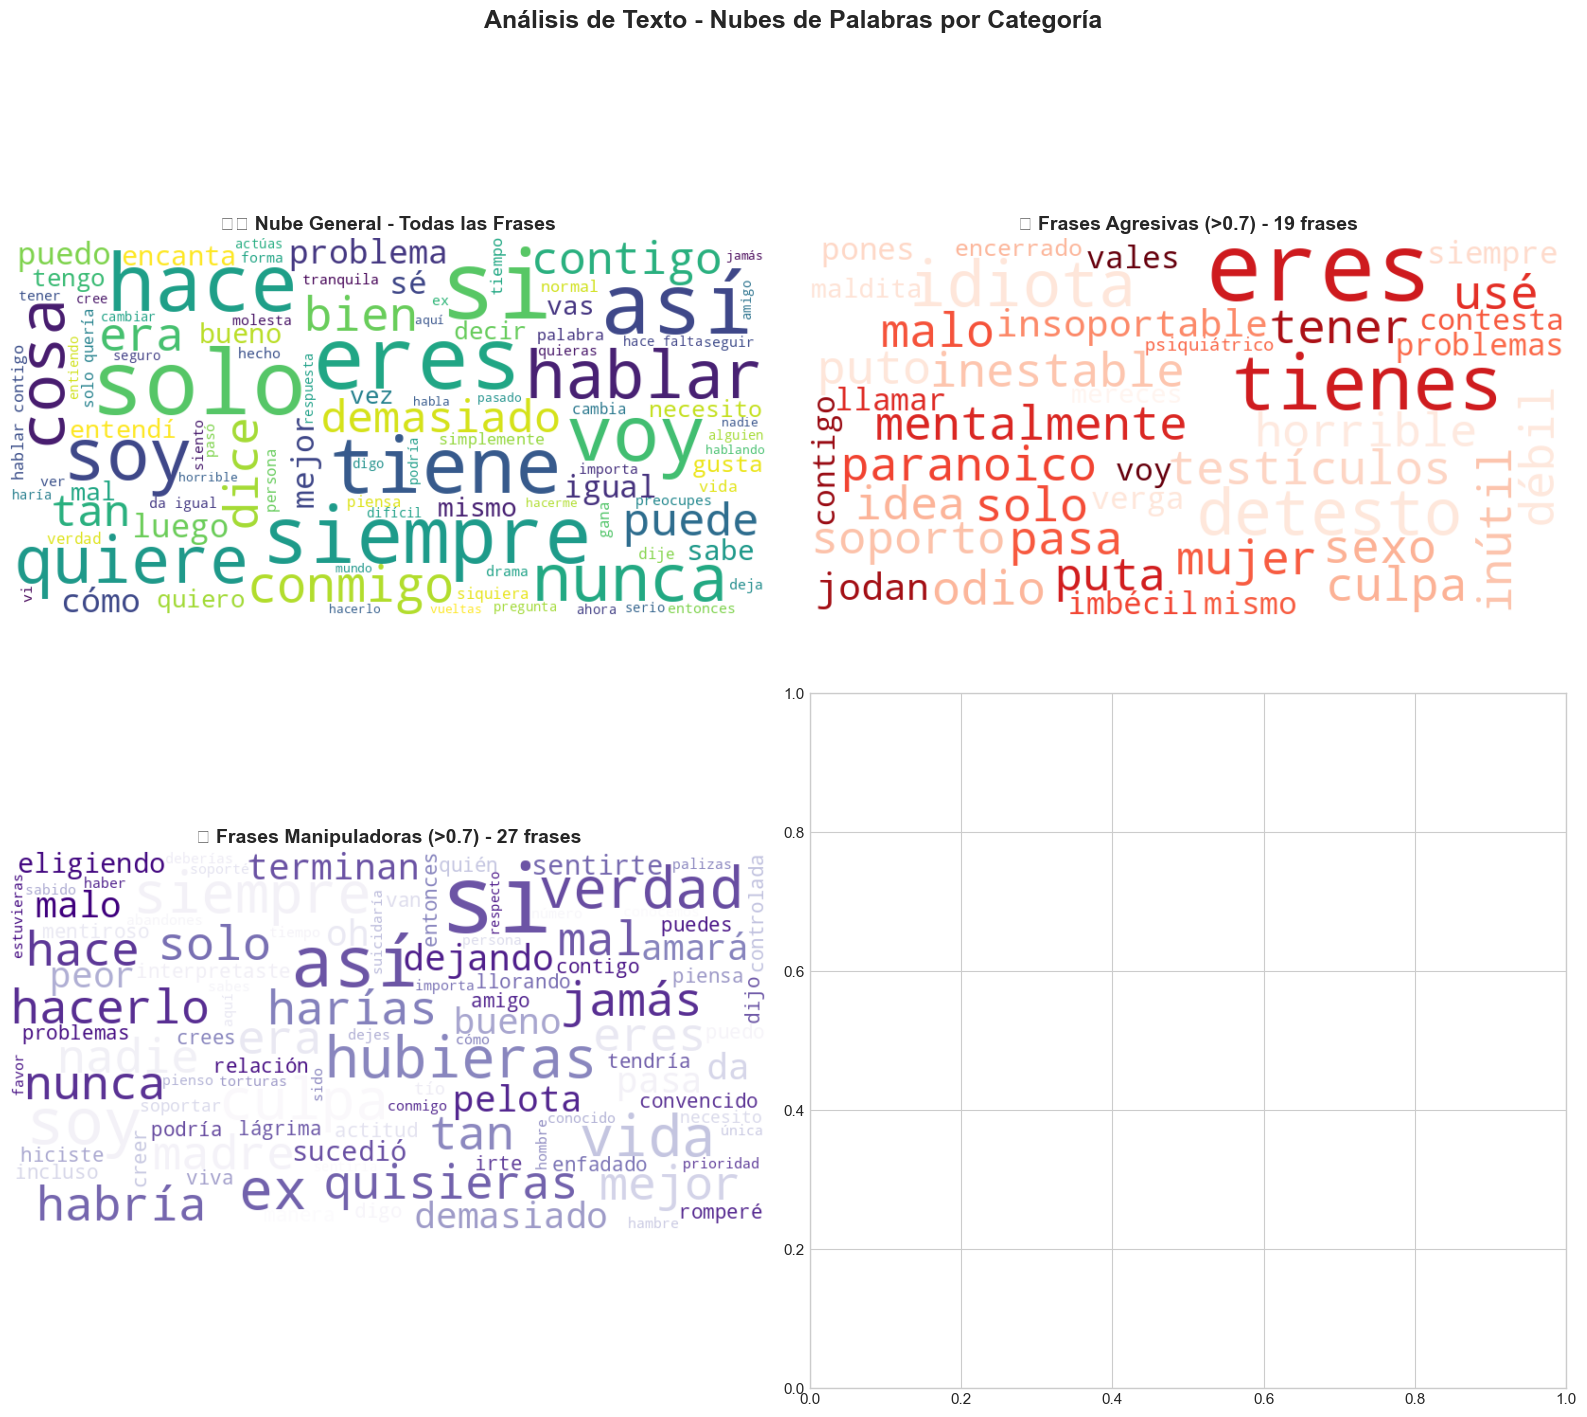

In [38]:
# Figura con 4 nubes de palabras
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# Nube general
wc_general = generar_nube_palabras(df['frase_limpia'].tolist(), 'General', 'viridis')
if wc_general:
    axes[0, 0].imshow(wc_general, interpolation='bilinear')
    axes[0, 0].set_title('☁️ Nube General - Todas las Frases', fontsize=14, fontweight='bold')
    axes[0, 0].axis('off')

# Nube para frases agresivas (umbral > 0.7)
frases_agresivas = df[df['agresividad'] > 0.7]['frase_limpia'].tolist()
wc_agresiva = generar_nube_palabras(frases_agresivas, 'Agresivas', 'Reds')
if wc_agresiva:
    axes[0, 1].imshow(wc_agresiva, interpolation='bilinear')
    axes[0, 1].set_title(f'😠 Frases Agresivas (>0.7) - {len(frases_agresivas)} frases', 
                          fontsize=14, fontweight='bold')
    axes[0, 1].axis('off')

# Nube para frases manipuladoras (umbral > 0.7)
frases_manipulacion = df[df['manipulacion'] > 0.7]['frase_limpia'].tolist()
wc_manipulacion = generar_nube_palabras(frases_manipulacion, 'Manipulación', 'Purples')
if wc_manipulacion:
    axes[1, 0].imshow(wc_manipulacion, interpolation='bilinear')
    axes[1, 0].set_title(f'🎭 Frases Manipuladoras (>0.7) - {len(frases_manipulacion)} frases', 
                          fontsize=14, fontweight='bold')
    axes[1, 0].axis('off')

# Nube para frases sarcásticas (umbral > 0.7)
frases_sarcasmo = df[df['sarcasmo'] > 0.7]['frase_limpia'].tolist()
wc_sarcasmo = generar_nube_palabras(frases_sarcasmo, 'Sarcasmo', 'YlOrBr')
if wc_sarcasmo:
    axes[1, 1].imshow(wc_sarcasmo, interpolation='bilinear')
    axes[1, 1].set_title(f'😏 Frases Sarcásticas (>0.7) - {len(frases_sarcasmo)} frases', 
                          fontsize=14, fontweight='bold')
    axes[1, 1].axis('off')

plt.suptitle('Análisis de Texto - Nubes de Palabras por Categoría', 
             fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('06_nubes_palabras.png', dpi=150, bbox_inches='tight')
plt.show()


### ANÁLISIS DE PALABRAS MÁS FRECUENTES POR CATEGORÍA

In [39]:
def obtener_palabras_frecuentes(textos, n=20):
    """Obtiene las n palabras más frecuentes"""
    todas_palabras = []
    for texto in textos:
        palabras = str(texto).lower().split()
        palabras = [p for p in palabras if p not in stopwords_es and len(p) > 2]
        todas_palabras.extend(palabras)
    return Counter(todas_palabras).most_common(n)


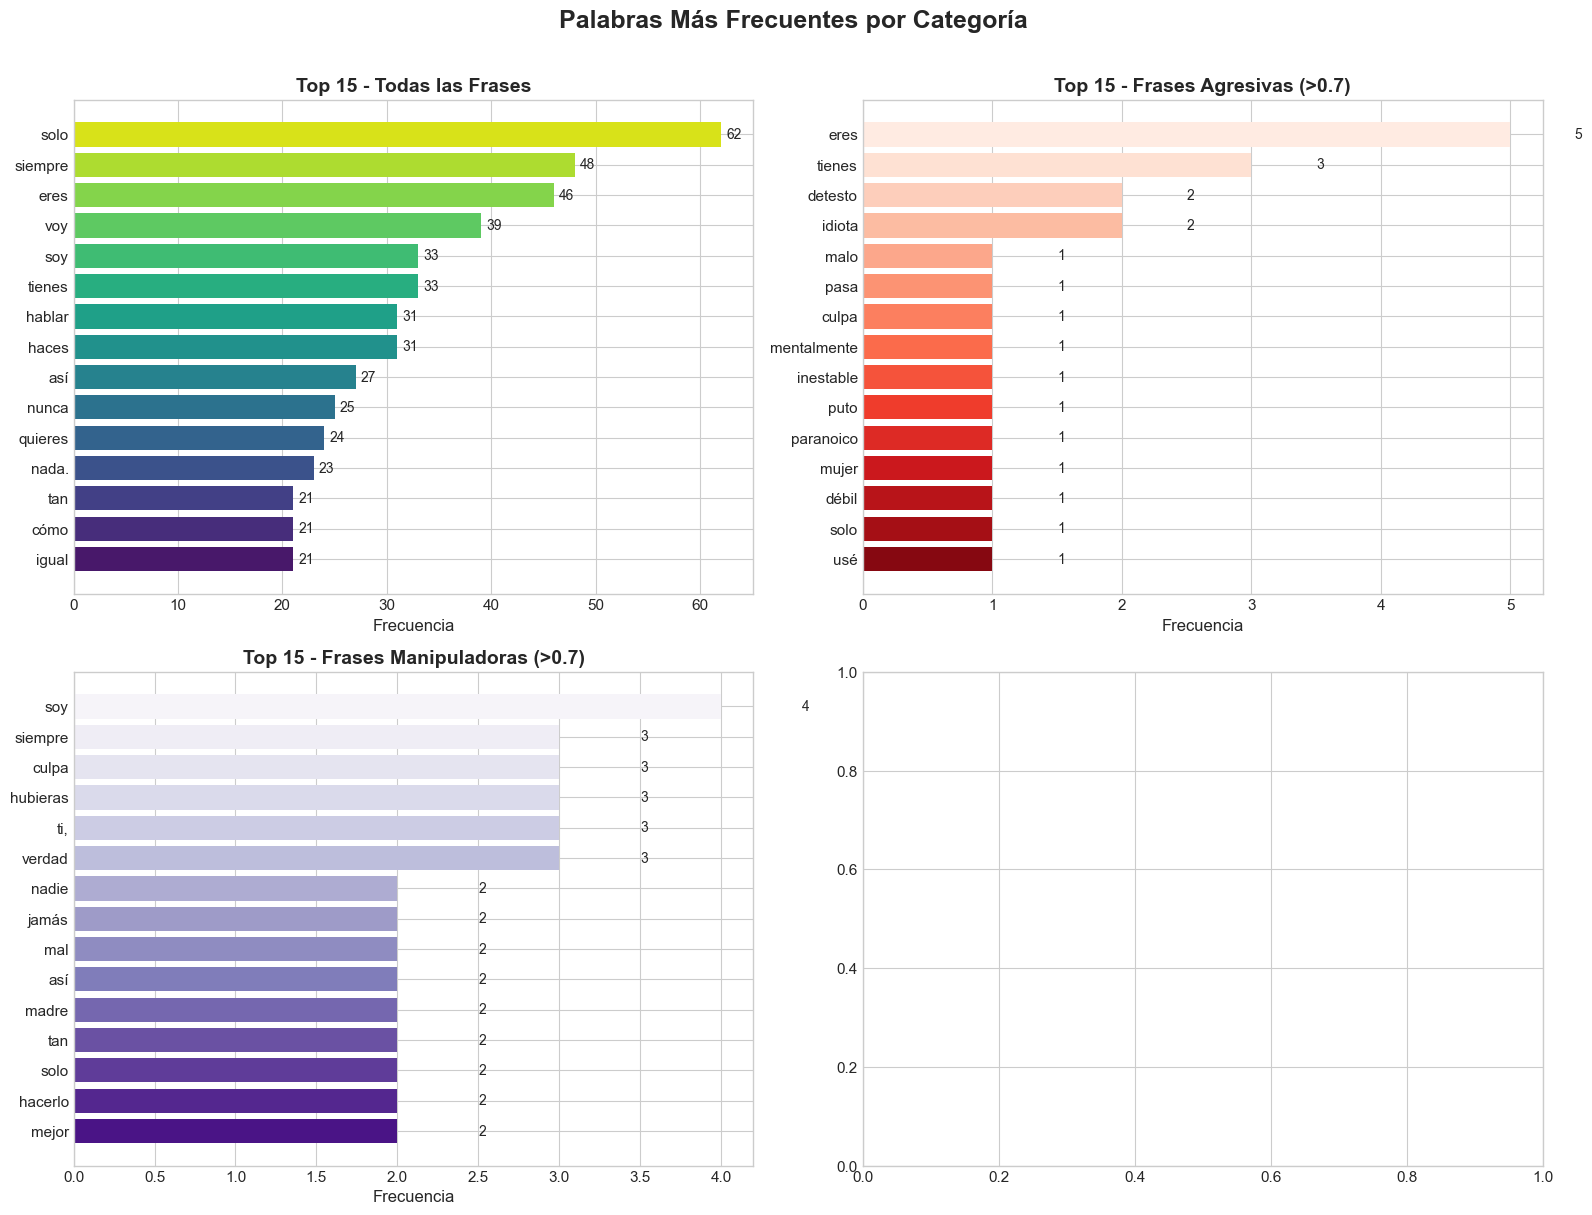

In [40]:
# Figura con las palabras más frecuentes por categoría
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

umbrales = [
    (df['frase_limpia'].tolist(), 'Todas las Frases', 'viridis'),
    (df[df['agresividad'] > 0.7]['frase_limpia'].tolist(), 'Frases Agresivas (>0.7)', 'Reds_r'),
    (df[df['manipulacion'] > 0.7]['frase_limpia'].tolist(), 'Frases Manipuladoras (>0.7)', 'Purples_r'),
    (df[df['sarcasmo'] > 0.7]['frase_limpia'].tolist(), 'Frases Sarcásticas (>0.7)', 'YlOrBr_r')
]

for idx, (textos, titulo, colormap) in enumerate(umbrales):
    ax = axes[idx // 2, idx % 2]
    
    freq_words = obtener_palabras_frecuentes(textos, n=15)
    
    if freq_words:
        palabras = [w[0] for w in freq_words]
        frecuencias = [w[1] for w in freq_words]
        
        bars = ax.barh(palabras[::-1], frecuencias[::-1], color=sns.color_palette(colormap, 15))
        ax.set_xlabel('Frecuencia', fontsize=12)
        ax.set_title(f'Top 15 - {titulo}', fontsize=14, fontweight='bold')
        
        # Añadir valores en las barras
        for bar, freq in zip(bars, frecuencias[::-1]):
            ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                   str(freq), va='center', fontsize=10)

plt.suptitle('Palabras Más Frecuentes por Categoría', fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('07_palabras_frecuentes.png', dpi=150, bbox_inches='tight')
plt.show()

### PREPARACIÓN DE DATOS PARA MODELADO

In [43]:
# Limpiar texto para modelado
def limpiar_texto_bert(texto):
    """Limpieza de texto optimizada para BERT"""
    if pd.isna(texto):
        return ""
    texto = str(texto).lower().strip()
    texto = re.sub(r'[^\w\sáéíóúñü¿¡.,;!?]', '', texto)
    texto = re.sub(r'\s+', ' ', texto)
    return texto.strip()

In [44]:
# Usar frases limpias
frases = df['frase_limpia'].tolist()
etiquetas = df[['agresividad', 'manipulacion', 'sarcasmo']].values.astype(np.float32)

# División de datos: 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    frases, etiquetas, 
    test_size=0.30,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, 
    test_size=0.50,
    random_state=42
)

In [47]:
print(f"\nDivisión de datos:")
print(f"   Entrenamiento: {len(X_train)} frases ({len(X_train)/len(frases)*100:.1f}%)")
print(f"   Validación:    {len(X_val)} frases ({len(X_val)/len(frases)*100:.1f}%)")
print(f"   Prueba:        {len(X_test)} frases ({len(X_test)/len(frases)*100:.1f}%)")

# Verificar distribución de etiquetas en cada split
print(f"\nDistribución de etiquetas por split:")
for nombre, etiquetas_split in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    print(f"\n   {nombre}:")
    for idx, var in enumerate(nombres):
        print(f"      {var}: Media={etiquetas_split[:, idx].mean():.3f}, Std={etiquetas_split[:, idx].std():.3f}")



División de datos:
   Entrenamiento: 590 frases (69.9%)
   Validación:    127 frases (15.0%)
   Prueba:        127 frases (15.0%)

Distribución de etiquetas por split:

   Train:
      Agresividad: Media=0.281, Std=0.189
      Manipulación: Media=0.486, Std=0.149
      Sarcasmo: Media=0.253, Std=0.121

   Val:
      Agresividad: Media=0.276, Std=0.180
      Manipulación: Media=0.508, Std=0.159
      Sarcasmo: Media=0.238, Std=0.120

   Test:
      Agresividad: Media=0.287, Std=0.205
      Manipulación: Media=0.471, Std=0.155
      Sarcasmo: Media=0.226, Std=0.115


In [48]:
# Hiperparámetros
BATCH_SIZE = 8 if device.type == 'cuda' else 4  # Reducido para evitar overfitting
EPOCHS = 15
MAX_LEN = 128
LEARNING_RATE = 1e-5  # Reducido para fine-tuning
WEIGHT_DECAY = 0.01
WARMUP_STEPS = 50
PATIENCE = 4  # Early stopping más generoso

print(f"\n Hiperparámetros:")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Épocas máximas: {EPOCHS}")
print(f"   Max length: {MAX_LEN}")
print(f"   Learning rate: {LEARNING_RATE}")
print(f"   Weight decay: {WEIGHT_DECAY}")
print(f"   Warmup steps: {WARMUP_STEPS}")
print(f"   Patience (early stopping): {PATIENCE}")


 Hiperparámetros:
   Batch size: 4
   Épocas máximas: 15
   Max length: 128
   Learning rate: 1e-05
   Weight decay: 0.01
   Warmup steps: 50
   Patience (early stopping): 4


### CARGA DEL MODELO BERT Y TOKENIZER

In [49]:
model_name = "dccuchile/bert-base-spanish-wwm-uncased"

print(f"\nModelo: {model_name}")
print("   (BERT pre-entrenado en español - Wikipedia)")

tokenizer = AutoTokenizer.from_pretrained(model_name)

# IMPORTANTE: Usar problem_type="regression" para valores continuos
# Los logits de salida son directamente los valores predichos
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3,
    problem_type="regression"  # Clave: regresión multi-salida
)

model = model.to(device)

# Limpiar caché de GPU
if device.type == 'cuda':
    torch.cuda.empty_cache()

print(f"\nModelo cargado en {device}")
print(f"Parámetros del modelo: {sum(p.numel() for p in model.parameters()):,}")
print(f"Parámetros entrenables: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


Modelo: dccuchile/bert-base-spanish-wwm-uncased
   (BERT pre-entrenado en español - Wikipedia)


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 25277.71it/s]
BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPE


Modelo cargado en cpu
Parámetros del modelo: 109,853,187
Parámetros entrenables: 109,853,187


### DATASET Y DATALOADERS

In [50]:
class FraseDataset(Dataset):
    """Dataset personalizado para frases con múltiples etiquetas continuas"""
    
    def __init__(self, frases, etiquetas, tokenizer, max_len):
        self.frases = frases
        self.etiquetas = etiquetas
        self.tokenizer = tokenizer
        self.max_len = max_len
    
    def __len__(self):
        return len(self.frases)
    
    def __getitem__(self, idx):
        frase = str(self.frases[idx])
        etiqueta = self.etiquetas[idx]
        
        encoding = self.tokenizer(
            frase,
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(etiqueta, dtype=torch.float32)
        }

In [51]:
# Crear datasets
train_dataset = FraseDataset(X_train, y_train, tokenizer, MAX_LEN)
val_dataset = FraseDataset(X_val, y_val, tokenizer, MAX_LEN)
test_dataset = FraseDataset(X_test, y_test, tokenizer, MAX_LEN)

# Crear dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [52]:
print(f"Datasets creados:")
print(f"   Train: {len(train_dataset)} muestras")
print(f"   Val:   {len(val_dataset)} muestras")
print(f"   Test:  {len(test_dataset)} muestras")



Datasets creados:
   Train: 590 muestras
   Val:   127 muestras
   Test:  127 muestras


In [53]:
# Verificar un batch
batch_prueba = next(iter(train_loader))
print(f"\nEjemplo de batch:")
print(f"   input_ids shape: {batch_prueba['input_ids'].shape}")
print(f"   attention_mask shape: {batch_prueba['attention_mask'].shape}")
print(f"   labels shape: {batch_prueba['labels'].shape}")
print(f"   labels ejemplo: {batch_prueba['labels'][0]}")


Ejemplo de batch:
   input_ids shape: torch.Size([4, 128])
   attention_mask shape: torch.Size([4, 128])
   labels shape: torch.Size([4, 3])
   labels ejemplo: tensor([0.2000, 0.4000, 0.4000])


### CONFIGURACIÓN DE OPTIMIZADOR Y SCHEDULER

In [55]:
# Optimizador AdamW
optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# Scheduler con warmup
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=WARMUP_STEPS,
    num_training_steps=total_steps
)

print(f"Configuración de entrenamiento:")
print(f"   Total de steps: {total_steps}")
print(f"   Warmup steps: {WARMUP_STEPS}")
print(f"   Steps por época: {len(train_loader)}")

# Variables para tracking
train_losses = []
val_losses = []
train_r2_scores = []
val_r2_scores = []

Configuración de entrenamiento:
   Total de steps: 2220
   Warmup steps: 50
   Steps por época: 148


### FUNCIÓN DE ENTRENAMIENTO

In [56]:
def train_epoch(model, data_loader, optimizer, device, scheduler):
    """Entrena una época completa"""
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    for batch in data_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        optimizer.zero_grad()
        
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        
        loss = outputs.loss
        total_loss += loss.item()
        
        loss.backward()
        
        # Gradient clipping para estabilidad
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        scheduler.step()
        
        # ⚠️ IMPORTANTE: En regresión, los logits SON los valores predichos
        # NO aplicar sigmoid porque los valores ya son continuos
        preds = outputs.logits.detach().cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
    
    avg_loss = total_loss / len(data_loader)
    
    # Calcular R2 promedio
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    r2_scores = [r2_score(all_labels[:, i], all_preds[:, i]) for i in range(3)]
    avg_r2 = np.mean(r2_scores)
    
    return avg_loss, avg_r2, r2_scores

def eval_epoch(model, data_loader, device):
    """Evalúa una época completa"""
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            
            total_loss += outputs.loss.item()
            
            # Sin sigmoid en regresión
            preds = outputs.logits.cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())
    
    avg_loss = total_loss / len(data_loader)
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    r2_scores = [r2_score(all_labels[:, i], all_preds[:, i]) for i in range(3)]
    avg_r2 = np.mean(r2_scores)
    
    return avg_loss, avg_r2, r2_scores, all_preds, all_labels

### ENTRENAMIENTO DEL MODELO

In [57]:
best_val_loss = float('inf')
best_val_r2 = -float('inf')
patience_counter = 0
start_time = time.time()

for epoch in range(EPOCHS):
    epoch_start = time.time()
    
    # Entrenamiento
    train_loss, train_r2, train_r2_scores = train_epoch(
        model, train_loader, optimizer, device, scheduler
    )
    train_losses.append(train_loss)
    train_r2_scores.append(train_r2)
    
    # Validación
    val_loss, val_r2, val_r2_scores, _, _ = eval_epoch(model, val_loader, device)
    val_losses.append(val_loss)
    val_r2_scores.append(val_r2)
    
    epoch_time = time.time() - epoch_start
    total_time = time.time() - start_time
    
    # Imprimir progreso
    print(f"\n📊 Época {epoch+1}/{EPOCHS}")
    print(f"   Train: Loss={train_loss:.4f} | R²={train_r2:.4f} " +
          f"[A:{train_r2_scores[0]:.3f}, M:{train_r2_scores[1]:.3f}, S:{train_r2_scores[2]:.3f}]")
    print(f"   Val:   Loss={val_loss:.4f} | R²={val_r2:.4f} " +
          f"[A:{val_r2_scores[0]:.3f}, M:{val_r2_scores[1]:.3f}, S:{val_r2_scores[2]:.3f}]")
    print(f"   Time: {epoch_time:.1f}s | Total: {total_time/60:.1f}min")
    
    # Early stopping basado en val_loss Y val_r2
    if val_loss < best_val_loss and val_r2 > best_val_r2:
        best_val_loss = val_loss
        best_val_r2 = val_r2
        patience_counter = 0
        
        # Guardar mejor modelo
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'val_r2': val_r2,
        }, 'mejor_modelo_bert.pth')
        
        print(f"   ✨ MEJOR MODELO GUARDADO (Loss: {val_loss:.4f}, R²: {val_r2:.4f})")
    else:
        patience_counter += 1
        print(f"   ⏳ Sin mejora ({patience_counter}/{PATIENCE})")
        
        if patience_counter >= PATIENCE:
            print(f"\n🛑 EARLY STOPPING en época {epoch+1}")
            break

total_time = time.time() - start_time
print(f"\nEntrenamiento completado en {total_time/60:.1f} minutos")
print(f"Mejor Val Loss: {best_val_loss:.4f}")
print(f"Mejor Val R²: {best_val_r2:.4f}")


📊 Época 1/15
   Train: Loss=0.0482 | R²=-1.0200 [A:-1.003, M:-0.801, S:-1.256]
   Val:   Loss=0.0193 | R²=0.1703 [A:0.252, M:0.208, S:0.051]
   Time: 351.5s | Total: 5.9min
   ✨ MEJOR MODELO GUARDADO (Loss: 0.0193, R²: 0.1703)

📊 Época 2/15
   Train: Loss=0.0188 | R²=0.1670 [A:0.346, M:0.193, S:-0.038]
   Val:   Loss=0.0175 | R²=0.2723 [A:0.308, M:0.204, S:0.304]
   Time: 291.9s | Total: 10.7min
   ✨ MEJOR MODELO GUARDADO (Loss: 0.0175, R²: 0.2723)

📊 Época 3/15
   Train: Loss=0.0146 | R²=0.3429 [A:0.530, M:0.313, S:0.185]
   Val:   Loss=0.0151 | R²=0.3728 [A:0.338, M:0.419, S:0.362]
   Time: 288.2s | Total: 15.6min
   ✨ MEJOR MODELO GUARDADO (Loss: 0.0151, R²: 0.3728)

📊 Época 4/15
   Train: Loss=0.0111 | R²=0.5049 [A:0.612, M:0.532, S:0.371]
   Val:   Loss=0.0145 | R²=0.3749 [A:0.407, M:0.455, S:0.262]
   Time: 288.0s | Total: 20.4min
   ✨ MEJOR MODELO GUARDADO (Loss: 0.0145, R²: 0.3749)

📊 Época 5/15
   Train: Loss=0.0092 | R²=0.5768 [A:0.705, M:0.617, S:0.408]
   Val:   Loss=0.013

### CURVAS DE APRENDIZAJE

TypeError: 'numpy.float64' object is not iterable

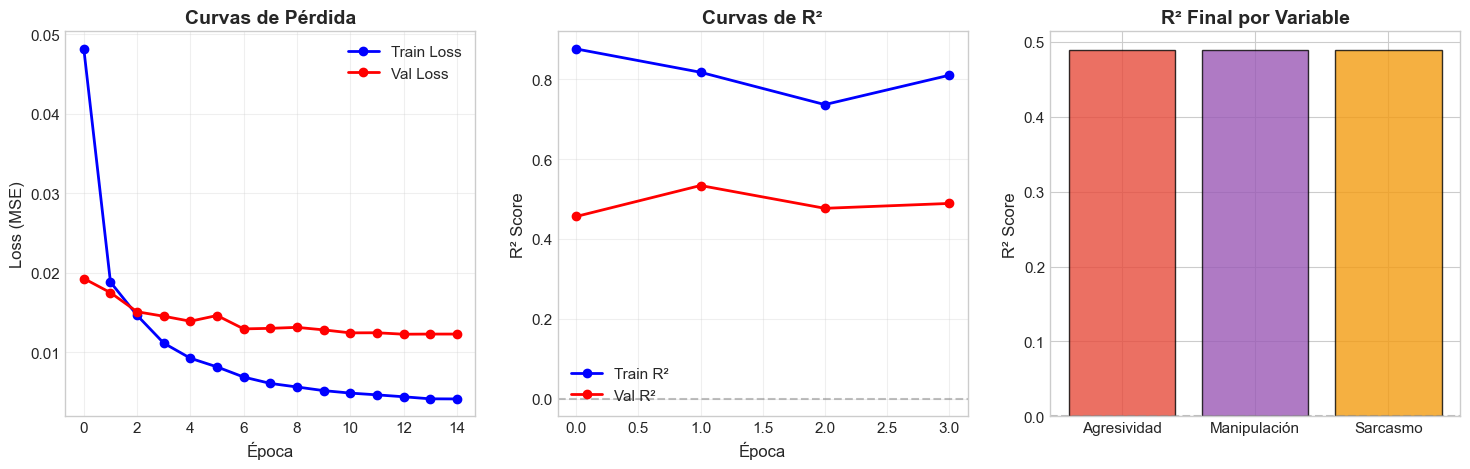

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
ax1 = axes[0]
ax1.plot(train_losses, 'b-o', label='Train Loss', linewidth=2, markersize=6)
ax1.plot(val_losses, 'r-o', label='Val Loss', linewidth=2, markersize=6)
ax1.set_xlabel('Época')
ax1.set_ylabel('Loss (MSE)')
ax1.set_title('Curvas de Pérdida', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# R2 Score
ax2 = axes[1]
ax2.plot(train_r2_scores, 'b-o', label='Train R²', linewidth=2, markersize=6)
ax2.plot(val_r2_scores, 'r-o', label='Val R²', linewidth=2, markersize=6)
ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax2.set_xlabel('Época')
ax2.set_ylabel('R² Score')
ax2.set_title('Curvas de R²', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# R2 por variable en última época
ax3 = axes[2]
r2_labels = ['Agresividad', 'Manipulación', 'Sarcasmo']
r2_colors = colores
bars = ax3.bar(r2_labels, val_r2_scores[-1], color=r2_colors, edgecolor='black', alpha=0.8)
ax3.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax3.set_ylabel('R² Score')
ax3.set_title('R² Final por Variable', fontsize=14, fontweight='bold')

for bar, r2 in zip(bars, val_r2_scores[-1]):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{r2:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax3.grid(True, alpha=0.3, axis='y')

plt.suptitle('Análisis del Entrenamiento', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('12_curvas_aprendizaje.png', dpi=150, bbox_inches='tight')
plt.show()

In [61]:
def predecir_frase(frase, modelo, tokenizer, device, max_len=128):
    """
    Predice agresividad, manipulación y sarcasmo para una frase nueva.
    
    Args:
        frase: Texto a analizar
        modelo: Modelo BERT entrenado
        tokenizer: Tokenizador BERT
        device: Dispositivo (cuda/cpu)
        max_len: Longitud máxima del texto
        
    Returns:
        dict: Diccionario con las 3 predicciones
    """
    modelo.eval()
    
    # Limpiar texto
    frase_limpia = limpiar_texto_bert(frase)
    
    # Tokenizar
    encoding = tokenizer(
        frase_limpia,
        truncation=True,
        padding='max_length',
        max_length=max_len,
        return_tensors='pt'
    )
    
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)
    
    # Predecir
    with torch.no_grad():
        outputs = modelo(input_ids=input_ids, attention_mask=attention_mask)
        # ⚠️ IMPORTANTE: NO aplicar sigmoid en regresión
        predictions = outputs.logits.cpu().numpy()[0]
    
    # Clipping para asegurar [0, 1]
    predictions = np.clip(predictions, 0, 1)
    
    return {
        'agresividad': round(float(predictions[0]), 3),
        'manipulacion': round(float(predictions[1]), 3),
        'sarcasmo': round(float(predictions[2]), 3)
    }

def interpretar_resultado(resultado):
    """Interpreta los resultados de la predicción"""
    interpretacion = []
    
    if resultado['agresividad'] > 0.7:
        interpretacion.append("😠 Alta agresividad detectada")
    elif resultado['agresividad'] > 0.4:
        interpretacion.append("😐 Agresividad moderada")
    else:
        interpretacion.append("😌 Baja agresividad")
    
    if resultado['manipulacion'] > 0.7:
        interpretacion.append("🎭 Alta manipulación detectada")
    elif resultado['manipulacion'] > 0.4:
        interpretacion.append("😐 Manipulación moderada")
    else:
        interpretacion.append("😌 Baja manipulación")
    
    if resultado['sarcasmo'] > 0.7:
        interpretacion.append("😏 Alto sarcasmo detectado")
    elif resultado['sarcasmo'] > 0.4:
        interpretacion.append("😐 Sarcasmo moderado")
    else:
        interpretacion.append("😌 Bajo sarcasmo")
    
    return interpretacion

print("✅ Función de predicción definida")

✅ Función de predicción definida



FRASE                                               AGRES  MANIP   SARC INTERPRETACIÓN                
Eres un inútil, todo lo haces mal                   0.556  0.583  0.216 agresividad                   
Ojalá te mueras, no sirves para nada                0.468  0.588  0.201 agresividad                   
Me das asco, no quiero verte nunca más              0.705  0.502  0.085 agresividad                   
Si de verdad me quisieras, harías lo que te pido    0.306  0.925  0.023 manipulación                  
Yo te quiero mucho, pero tú me haces actuar así     0.359  0.650  0.231 manipulación                  
Nadie te va a querer como yo, no te vayas           0.337  0.696  0.165 manipulación                  
Claro, seguro que eres un genio... (guiño guiño)    0.396  0.429  0.433 sarcasmo                      
Qué inteligente eres, en serio...                   0.337  0.378  0.317 sarcasmo                      
Brillante idea, de verdad te felicito               0.190  0.246  0.256 

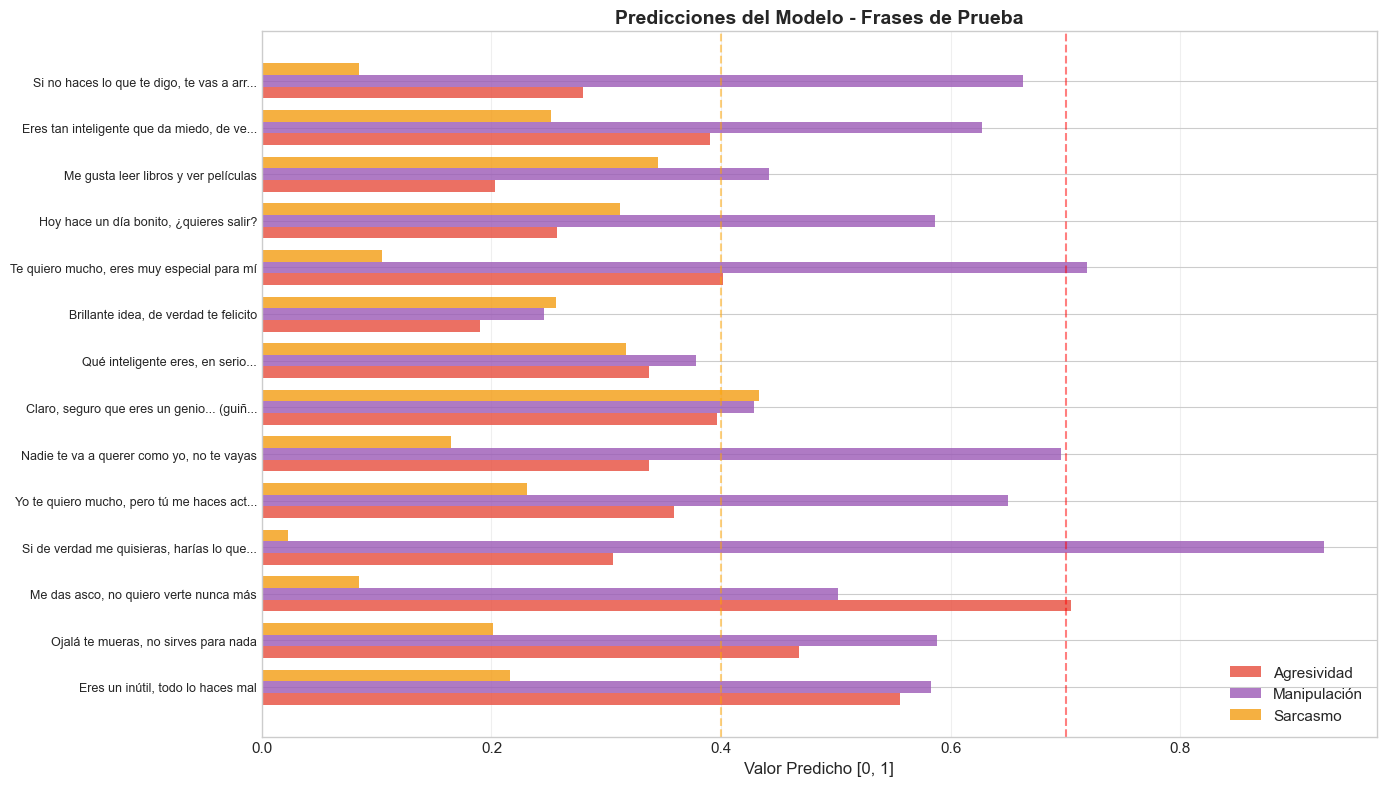

In [65]:
frases_prueba = [
    # Agresivas
    ("Eres un inútil, todo lo haces mal", "agresividad"),
    ("Ojalá te mueras, no sirves para nada", "agresividad"),
    ("Me das asco, no quiero verte nunca más", "agresividad"),
    
    # Manipuladoras
    ("Si de verdad me quisieras, harías lo que te pido", "manipulación"),
    ("Yo te quiero mucho, pero tú me haces actuar así", "manipulación"),
    ("Nadie te va a querer como yo, no te vayas", "manipulación"),
    
    # Sarcásticas
    ("Claro, seguro que eres un genio... (guiño guiño)", "sarcasmo"),
    ("Qué inteligente eres, en serio...", "sarcasmo"),
    ("Brillante idea, de verdad te felicito", "sarcasmo"),
    
    # Neutras/Bajas
    ("Te quiero mucho, eres muy especial para mí", "Baja en todo"),
    ("Hoy hace un día bonito, ¿quieres salir?", "Baja en todo"),
    ("Me gusta leer libros y ver películas", "Baja en todo"),
    
    # Mixtas
    ("Eres tan inteligente que da miedo, de verdad te admiro... no sé cómo puedo soportarte", "Mixto"),
    ("Si no haces lo que te digo, te vas a arrepentir, pero es por tu bien", "manipulación"),
]

print(f"\n{'='*80}")
print(f"{'FRASE':<50} {'AGRES':>6} {'MANIP':>6} {'SARC':>6} {'INTERPRETACIÓN':<30}")
print(f"{'='*80}")

resultados_prueba = []

for frase, expectativa in frases_prueba:
    resultado = predecir_frase(frase, model, tokenizer, device)
    interpretacion = interpretar_resultado(resultado)[0].split(" ")[1]  # Primer nivel
    
    # Acortar frase para display
    frase_display = frase[:47] + "..." if len(frase) > 50 else frase
    
    print(f"{frase_display:<50} {resultado['agresividad']:>6.3f} {resultado['manipulacion']:>6.3f} {resultado['sarcasmo']:>6.3f} {expectativa:<30}")
    
    resultados_prueba.append({
        'frase': frase,
        'expectativa': expectativa,
        **resultado
    })

print(f"{'='*80}")

# Visualización de las pruebas
fig, ax = plt.subplots(figsize=(14, 8))

x = np.arange(len(frases_prueba))
width = 0.25

bars1 = ax.barh(x - width, [r['agresividad'] for r in resultados_prueba], width, 
               label='Agresividad', color=colores[0], alpha=0.8)
bars2 = ax.barh(x, [r['manipulacion'] for r in resultados_prueba], width,
               label='Manipulación', color=colores[1], alpha=0.8)
bars3 = ax.barh(x + width, [r['sarcasmo'] for r in resultados_prueba], width,
               label='Sarcasmo', color=colores[2], alpha=0.8)

# Acortar etiquetas
frases_cortas = [f[:40] + "..." if len(f) > 43 else f for f in [r['frase'] for r in resultados_prueba]]
ax.set_yticks(x)
ax.set_yticklabels(frases_cortas, fontsize=9)
ax.set_xlabel('Valor Predicho [0, 1]')
ax.set_title('Predicciones del Modelo - Frases de Prueba', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.axvline(x=0.7, color='red', linestyle='--', alpha=0.5, label='Umbral alto')
ax.axvline(x=0.4, color='orange', linestyle='--', alpha=0.5, label='Umbral medio')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('15_pruebas_modelo.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Paths de guardado
model_save_path = './modelo_bert_toxico'
tokenizer_save_path = './modelo_bert_toxico'

# Guardar modelo y tokenizer
model.save_pretrained(model_save_path)
tokenizer.save_pretrained(tokenizer_save_path)

print(f"\nModelo guardado en: {model_save_path}")
print(f"Tokenizer guardado en: {tokenizer_save_path}")

# Listar archivos guardados
import os
print(f"\nArchivos guardados:")
for archivo in os.listdir(model_save_path):
    tamaño = os.path.getsize(os.path.join(model_save_path, archivo))
    if tamaño > 1024*1024:
        tamaño_str = f"{tamaño/(1024*1024):.2f} MB"
    else:
        tamaño_str = f"{tamaño/1024:.2f} KB"
    print(f"   {archivo}: {tamaño_str}")

print(f"\nPara cargar el modelo en el futuro:")
print(f"""
from transformers import AutoTokenizer, AutoModelForSequenceClassification

tokenizer = AutoTokenizer.from_pretrained('{model_save_path}')
model = AutoModelForSequenceClassification.from_pretrained('{model_save_path}')
""")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.13it/s]


✅ Modelo guardado en: ./modelo_bert_toxico
✅ Tokenizer guardado en: ./modelo_bert_toxico

📁 Archivos guardados:
   config.json: 0.99 KB
   model.safetensors: 419.08 MB
   tokenizer.json: 718.31 KB
   tokenizer_config.json: 0.38 KB

📝 Para cargar el modelo en el futuro:

from transformers import AutoTokenizer, AutoModelForSequenceClassification

tokenizer = AutoTokenizer.from_pretrained('./modelo_bert_toxico')
model = AutoModelForSequenceClassification.from_pretrained('./modelo_bert_toxico')

